# **Lab 2**

**Data Cleaning: Handling Duplicates**

In [1]:
import pandas as pd
import numpy as np

# 1. Load the massive dataset
filename = "final.zip" # Change this to your actual file name
print(f"Loading massive dataset: {filename}...")

# We load 'date' directly as a datetime object for faster processing
df = pd.read_csv(filename, parse_dates=['date'])
print(f"Original Row Count: {len(df):,}")

# 1. Count how many rows we started with
initial_rows = len(df)

# 2. Drop the clones
# We strictly check the combination of Date, Province, and Municipality.
df = df.drop_duplicates(subset=['date', 'Province', 'Municipality'])

# 3. Print the results so you know exactly how many errors were fixed
duplicates_removed = initial_rows - len(df)
print(f"Scrubbed {duplicates_removed:,} duplicate rows.")

Loading massive dataset: final.zip...
Original Row Count: 585,312
Scrubbed 0 duplicate rows.


**Data Cleaning: Handling Missing Data**

In [2]:
# We use Linear Interpolation. This means the computer draws a straight mathematical line between 
# the day before and the day after the missing data.
weather_columns = [
    "Max_Temp", "Min_Temp", "Mean_Temp", 
    "Precipitation_Sum", "Max_Wind_Speed", "Max_Wind_Gusts"
]

for col in weather_columns:
    # 1. Connect the dots for missing days (Interpolation)
    df[col] = df[col].interpolate(method='linear', limit_direction='both')
    
    # 2. Failsafe: If the very first row is missing, fill it with the column's average
    df[col] = df[col].fillna(df[col].mean())

**Data Handling: Memory Optimization**

In [3]:
# Loop through the weather columns and shrink their memory footprint
for col in weather_columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

# Then save the Master Clean File
output_name = "bicol_weather_cleaned_MASTER.zip"
df.to_csv(output_name, index=False)
print(f"\nBoom! Data cleaning complete. Final dataset saved as '{output_name}'.")
print(f"Final Row Count: {len(df):,}")


Boom! Data cleaning complete. Final dataset saved as 'bicol_weather_cleaned_MASTER.zip'.
Final Row Count: 585,312


**Data Visualizations:**

C:\Users\eljoh\AppData\Local\Temp\ipykernel_13436\1067531360.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_locations, x='Yield', y='Geolocation', palette='viridis')


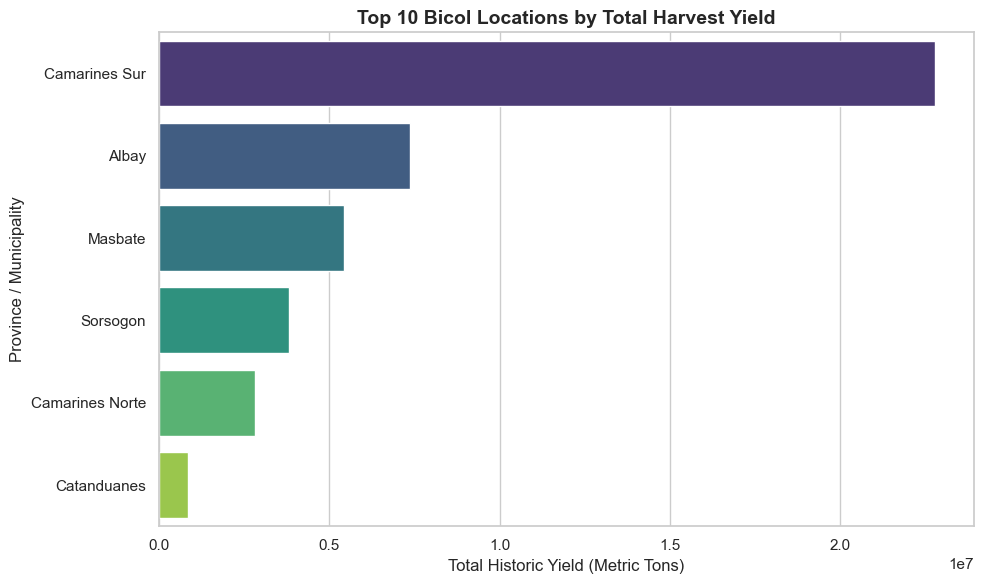

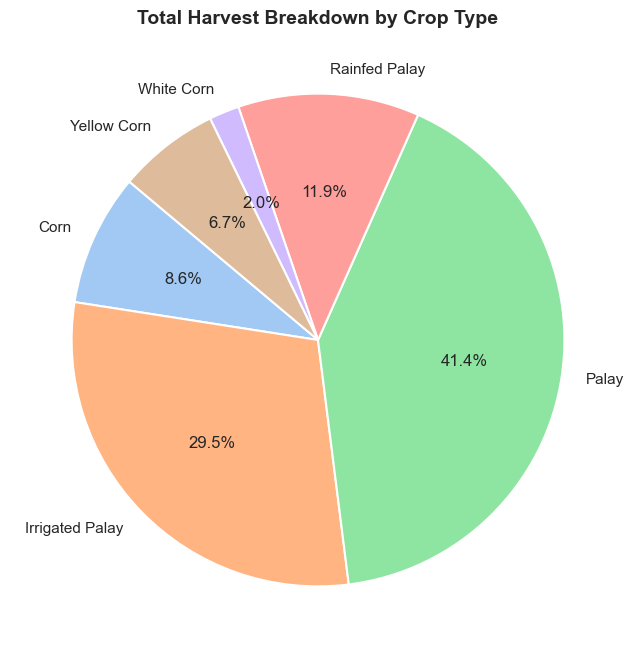

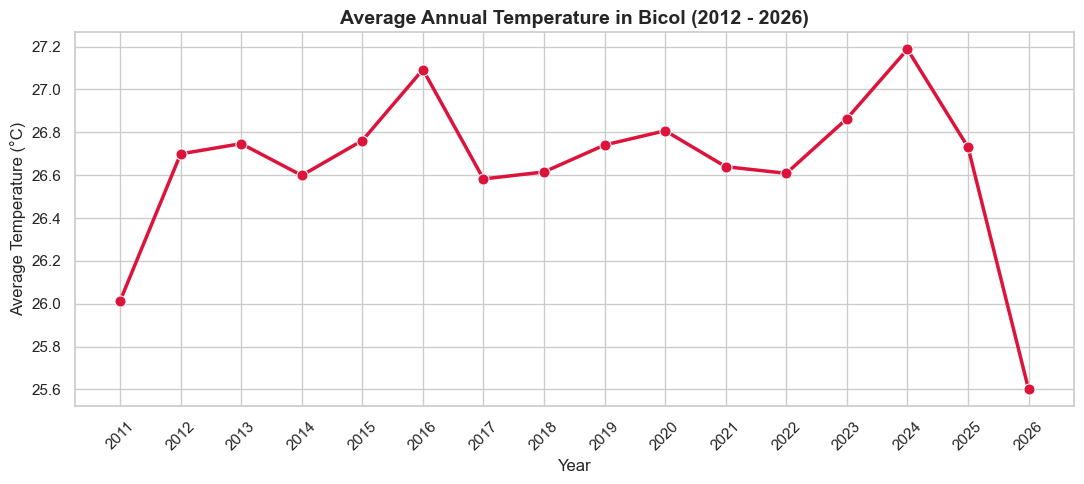

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# =====================================================================
# 1. LOAD AND PREP RAW DATA (No merging required!)
# =====================================================================
weather_df = pd.read_csv("bicol_weather_cleaned_MASTER.zip", parse_dates=['date'])
yield_df = pd.read_csv("rice_corn.csv")

# "Melt" the crop data so Pandas can read the numbers correctly
quarter_cols = [col for col in yield_df.columns if "Quarter" in col]
yield_long = yield_df.melt(
    id_vars=["Ecosystem/Croptype", "Geolocation"], 
    value_vars=quarter_cols, 
    var_name="Time_Period", 
    value_name="Yield"
)
# Clean commas and drop blanks
yield_long['Yield'] = pd.to_numeric(yield_long['Yield'].astype(str).str.replace(',', ''), errors='coerce')
yield_long = yield_long.dropna(subset=['Yield'])


# =====================================================================
# PLOT 1: Top 10 Locations by Total Harvest (Bar Chart)
# =====================================================================
plt.figure(figsize=(10, 6))

# Sum up the yield per location and grab the top 10
top_locations = yield_long.groupby('Geolocation')['Yield'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_locations, x='Yield', y='Geolocation', palette='viridis')
plt.title('Top 10 Bicol Locations by Total Harvest Yield', fontsize=14, fontweight='bold')
plt.xlabel('Total Historic Yield (Metric Tons)')
plt.ylabel('Province / Municipality')
plt.tight_layout()
plt.show()


# =====================================================================
# PLOT 2: Crop Yield Breakdown (Pie Chart)
# =====================================================================
plt.figure(figsize=(8, 8))

# Sum up the total yield for each specific type of crop
crop_totals = yield_long.groupby('Ecosystem/Croptype')['Yield'].sum()

# Draw the Pie Chart
plt.pie(
    crop_totals, 
    labels=crop_totals.index, 
    autopct='%1.1f%%', # Shows the percentages automatically!
    startangle=140, 
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Total Harvest Breakdown by Crop Type', fontsize=14, fontweight='bold')
plt.show()


# =====================================================================
# PLOT 3: Average Annual Temperature (2012 - 2026) (Line Chart)
# =====================================================================
plt.figure(figsize=(11, 5))

# Extract the Year from the weather data and calculate the average temperature
weather_df['Year'] = weather_df['date'].dt.year
yearly_temp = weather_df.groupby('Year')['Mean_Temp'].mean().reset_index()

# Draw the Line Graph
sns.lineplot(
    data=yearly_temp, 
    x='Year', 
    y='Mean_Temp', 
    marker='o',       # Puts a distinct dot on every year
    color='crimson', 
    linewidth=2.5,
    markersize=8
)
plt.title('Average Annual Temperature in Bicol (2012 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.xticks(yearly_temp['Year'], rotation=45) # Forces every year to print on the X-axis
plt.tight_layout()
plt.show()